# 02 · EDA
**Proyecto Integrador – Data Mining Tools (CC209)** · TP1

Cubre el **Paso 3** (auditoría inicial) y el **Paso 4** (EDA guiado por preguntas).
En cada resultado se separa **lo que muestran los datos** de **lo que interpretamos**.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_FILE = ROOT / "data" / "raw" / "kc_house_data.csv"

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid")

## 3. Carga y auditoría inicial
Se trabaja sobre una copia en memoria: el archivo de `data/raw/` no se modifica.

In [2]:
df = pd.read_csv(RAW_FILE)
print(f"Forma: {df.shape}")
df.head()

Forma: (21613, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [3]:
df.describe().T[["min", "25%", "50%", "75%", "max"]]

,min,25%,50%,75%,max
id,1.000102e+06,2.123049e+09,3.904930e+09,7.308900e+09,9.900000e+09
price,7.500000e+04,3.219500e+05,4.500000e+05,6.450000e+05,7.700000e+06
bedrooms,0.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.300000e+01
bathrooms,0.000000e+00,1.750000e+00,2.250000e+00,2.500000e+00,8.000000e+00
sqft_living,2.900000e+02,1.427000e+03,1.910000e+03,2.550000e+03,1.354000e+04
sqft_lot,5.200000e+02,5.040000e+03,7.618000e+03,1.068800e+04,1.651359e+06
floors,1.000000e+00,1.000000e+00,1.500000e+00,2.000000e+00,3.500000e+00
waterfront,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
view,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
condition,1.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00


**Qué muestran los datos**
- `bedrooms` va de 0 a **33**, y `bathrooms` llega a 0: hay valores que parecen errores o casos especiales.
- `price` va de 75 mil a 7.7 millones, con una mediana de 450 mil: rango muy amplio.
- `sqft_lot` llega a 1.65 millones de pies² frente a una mediana de ~7 600: cola extrema.
- `yr_renovated` y `sqft_basement` tienen mediana 0 (ceros que significan "no aplica").

**Interpretación (hipótesis a verificar en los Pasos 4 y 5)**
- Las variables de tamaño y precio probablemente son muy asimétricas y requerirán transformación logarítmica.
- Los valores de 0 dormitorios/baños y los 33 dormitorios deben revisarse contra otras variables (por ejemplo `sqft_living`) antes de decidir si son errores.

### 3.1 Fecha de venta
`date` viene como texto (`YYYYMMDDT000000`). Se convierte a fecha **en la copia de trabajo**.

In [4]:
df["fecha"] = pd.to_datetime(df["date"], format="%Y%m%dT%H%M%S")
df["anio_venta"] = df["fecha"].dt.year
df["mes_venta"] = df["fecha"].dt.month

print("Rango:", df["fecha"].min().date(), "->", df["fecha"].max().date())
ventas_mes = df.groupby(df["fecha"].dt.to_period("M")).size().rename("ventas")
ventas_mes.to_frame()

Rango: 2014-05-02 -> 2015-05-27


,ventas
fecha,
2014-05,1768
2014-06,2180
2014-07,2211
2014-08,1940
2014-09,1774
2014-10,1878
2014-11,1411
2014-12,1471
2015-01,978


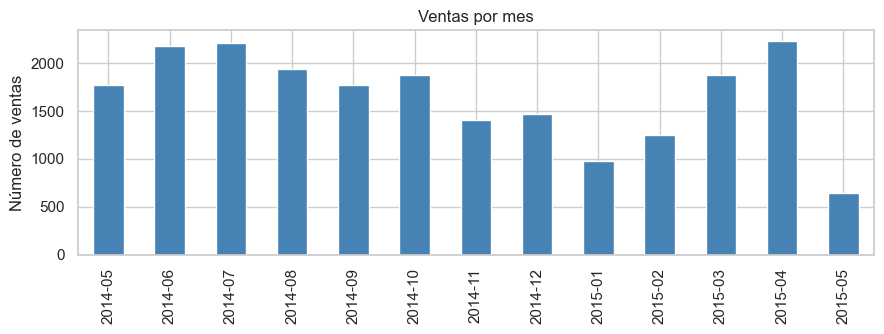

In [5]:
fig, ax = plt.subplots(figsize=(9, 3.5))
ventas_mes.plot.bar(ax=ax, color="steelblue")
ax.set_title("Ventas por mes")
ax.set_xlabel("")
ax.set_ylabel("Número de ventas")
plt.tight_layout()
plt.show()

**Qué muestran los datos**
- Hay entre ~1 000 y ~2 200 ventas por mes, con menos actividad en invierno (dic–feb).
- Mayo de 2015 tiene solo 646 ventas porque el registro termina el día 27, y mayo de 2014 empieza el día 2.

**Interpretación**
- La caída de mayo de 2015 es un efecto del corte del dataset, no del mercado.
- Con solo ~13 meses no se puede separar estacionalidad de tendencia: cualquier efecto de "mes" queda confundido con el año.

### 3.2 Unicidad de `id`: ventas repetidas

In [6]:
repetidos = df[df["id"].duplicated(keep=False)].sort_values(["id", "fecha"])

print(f"Filas totales:                   {len(df):,}")
print(f"id únicos:                       {df['id'].nunique():,}")
print(f"Viviendas vendidas más de 1 vez: {repetidos['id'].nunique():,} ({len(repetidos)} filas)")
print(f"Máximo de ventas por vivienda:   {repetidos.groupby('id').size().max()}")
print(f"Filas duplicadas exactas:        {df.drop(columns=['fecha', 'anio_venta', 'mes_venta']).duplicated().sum()}")
print(f"Mismo id y misma fecha:          {repetidos.duplicated(['id', 'fecha']).sum()}")

Filas totales:                   21,613
id únicos:                       21,436
Viviendas vendidas más de 1 vez: 176 (353 filas)
Máximo de ventas por vivienda:   3
Filas duplicadas exactas:        0
Mismo id y misma fecha:          0


In [7]:
cambio = repetidos.groupby("id")["price"].agg(primera="first", ultima="last")
cambio["variacion_%"] = (cambio["ultima"] / cambio["primera"] - 1) * 100
cambio["variacion_%"].describe().round(1).to_frame("variación de precio entre ventas (%)")

,variación de precio entre ventas (%)
count,176.0
mean,56.8
std,46.7
min,-5.4
25%,23.6
50%,54.4
75%,74.2
max,321.8


**Qué muestran los datos**
- **176 viviendas** aparecen más de una vez (353 filas, máximo 3 ventas). No hay filas duplicadas exactas ni dos ventas con el mismo `id` y la misma fecha.
- Entre la primera y la última venta, el precio sube una **mediana de ~54 %** (rango de −5 % a +322 %) en pocos meses.

**Interpretación**
- No son duplicados que haya que eliminar: son **ventas distintas** de la misma propiedad. Eliminarlas sería perder información.
- Una subida tan grande en menos de un año sugiere reventas con mejoras o compras para revender (*flipping*). Eso es relevante para la detección de anomalías, y es una hipótesis: el dataset no lo confirma.
- **Consecuencia para el split (Paso 6):** si una misma vivienda queda en train y en test, el modelo se evalúa con propiedades que ya vio. Hay que agrupar por `id`.